In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Visualisation Données

In [226]:
arbres = pd.read_csv("train.csv")
arbres = arbres.dropna()
arbres.head(2)

,ID_ARBRE,quartier,site,genre_arbre,situation,type_sol,surf_permeable,classe_age,hauteur,classe_hauteur,...,fissure_houppier,ecorce_incluse_houppier,bois_mort_houppier,plaie_houppier,observation_houppier,esperance_maintien,contrainte,classification_diagnostic,Long,Lat
0,0,Quartier 3 - Lycée International,RN13,Tilia,Alignement,MA,4.0,A,500,H1,...,HPF,Non,HPBM,HPLS,0,1.0,Non,C1,2.064,48.900
1,1,Quartier 2 - Alsace - Pereire,Avenue du Maréchal Foch,Tilia,Alignement,MA,4.0,A,800,H2,...,HFO,Non,HPBM,HPLNC,Fissure ouverte axe2 2M Sud Est,2.0,Oui,C4,2.085,48.903


In [75]:
prev = pd.read_csv("prev.csv")
prev.head()
x2 = prev[["type_sol", "classe_age", "classe_hauteur", "classe_circonference", "port_arbre", "vigueur_pousse", "plaie_collet", "fissure_tronc", "plaie_tronc", "fissure_houppier", "bois_mort_houppier", "plaie_houppier", "esperance_maintien"]]

In [228]:
x = arbres[["type_sol", "classe_age", "classe_hauteur", "classe_circonference", "port_arbre", "vigueur_pousse", "plaie_collet", "fissure_tronc", "plaie_tronc", "fissure_houppier", "bois_mort_houppier", "plaie_houppier", "esperance_maintien"]]
y = arbres[["classification_diagnostic"]]
x.head(2)

,type_sol,classe_age,classe_hauteur,classe_circonference,port_arbre,vigueur_pousse,plaie_collet,fissure_tronc,plaie_tronc,fissure_houppier,bois_mort_houppier,plaie_houppier,esperance_maintien
0,MA,A,H1,C1,R5,P,RCPPL,TPF,TPLS,HPF,HPBM,HPLS,1.0
1,MA,A,H2,C3,R5,P,RCPLS,TFO,TPLNC,HFO,HPBM,HPLNC,2.0


In [230]:
y.head(2)

,classification_diagnostic
0,C1
1,C4


## Entraînement - Calculs Probas - Classifieur de Bayes

In [224]:
#Retourne un array contenant les probabilité des chaque variable X du dataset
#On peut faire cela car nos variables prennent chacune leurs valeurs dans un ensemble fini.
#Autrement dit, nos variables sont discrètes.
def proba_x(X, X_values):
    return np.prod([(len(X[i][X[i]==j])/len(X)) for i, j in zip(X.columns, X_values)]) #Longueur de quantité(X_value)/longeur de dataset de ma colomne (ce qui équivaut aussi à la longueur de mon dataset selon l'axis=0)

In [83]:
proba_x(x, x.iloc[1].to_numpy()) # Je teste ma fonction proba avec une ligne de mon dataset "arbres"

5.713724494942144e-12

In [207]:
def proba_xsy_lisse(X, X_values, Y, Y_value):
    alpha = 0.1
    return np.prod([( len(X[ (X[i]==j) & (Y['classification_diagnostic'] == Y_value)]) + alpha ) / (len(Y[Y['classification_diagnostic'] == Y_value]) + alpha*len(np.unique(X[i])) ) for i, j in zip(X.columns, X_values)])

In [209]:
def proba_xsy(X, X_values, Y, Y_value):
    return np.prod([( len(X[ (X[i]==j) & (Y['classification_diagnostic'] == Y_value)])) / (len(Y[Y['classification_diagnostic'] == Y_value])) for i, j in zip(X.columns, X_values)])

In [211]:
def proba_y(Y, Y_value):
    return (len(y[y['classification_diagnostic']==Y_value])/len(y))

In [213]:
np.sum([proba_y(y, i) for i in np.unique(y)]) # On voit que la somme vaut 1 pour la somme de py(y)

1.0

In [215]:
def proba_ysx(X, X_values, Y, Y_value):
    return ( proba_xsy_lisse(X, X_values, Y, Y_value) * proba_y(y, Y_value) ) / proba_x(X, X_values)

In [217]:
[ proba_ysx(x, x.iloc[0].to_numpy(), y, c) for c in np.unique(y)]

[0.7312695830047634,
 0.257367343293223,
 0.003981231309430315,
 1.5220908054711875e-06,
 8.061420255376165e-08]

In [219]:
#def une_classe_predite_old(X, X_values, Y):
#    return classes[np.argmax([proba_ysx(X, X_values, Y, c) for c in classes])]
#def classifieur_bayes_old(X, Y):
#    return [une_classe_predite(X, X.iloc[i], Y) for i in range(len(X))]
#une_classe_predite(x, x.iloc[0], y)

In [221]:
def classifieur_bayes(X, Y):
    classes = np.unique(Y)
    return [classes[np.argmax([proba_ysx(X, X.iloc[i], Y, c) for c in classes])] for i in range(len(X))]

In [190]:
predict1 = classifieur_bayes(x, y)

In [193]:
def taux_erreur(predict, y):
    erreurs = len([i for i, j in zip(predict, y.to_numpy()) if i != j])
    taux = np.round((erreurs / len(y)) * 100, 5)
    print(f"Taux d'erreur : {taux}%")

In [195]:
taux_erreur(predict1, y)

Taux d'erreur : 23.52941%


In [197]:
def are(predict):
    erreurs = len([i for i, j in zip(predict, y.to_numpy().flatten()) if i == j])
    taux = np.round((erreurs / len(y)) * 100, 5)
    print(f"Average Classification Accuracy : {taux}%")

In [201]:
are(predict1)

Average Classification Accuracy : 76.47059%


In [79]:
def matrice_confusion():
    # On a stack le vecteur des prédictions ŷ (à gauche) avec le vecteur des vraies valeurs y (à droite).
    stack_predict_et_y = np.vstack((predict, y["classification_diagnostic"])).T
    classes_y = np.unique(y)
    confusion_matrix = np.zeros((len(classes_y), len(classes_y)), dtype = int)
    for i, c1 in enumerate(classes_y):
        for j, c2 in enumerate(classes_y):
            confusion_matrix[i][j] = np.sum((stack_predict_et_y[:, 0]==c2) & (stack_predict_et_y[:, 1]==c1))
    #res = np.hstack((confusion_matrix, classes_y))
    return confusion_matrix

matrice_confusion()

array([[138,  47,   0,   0,   0],
       [ 55, 253,   7,   0,   0],
       [  1,  13,  15,   2,   0],
       [  0,   0,   2,   5,   0],
       [  0,   0,   0,   1,   5]])

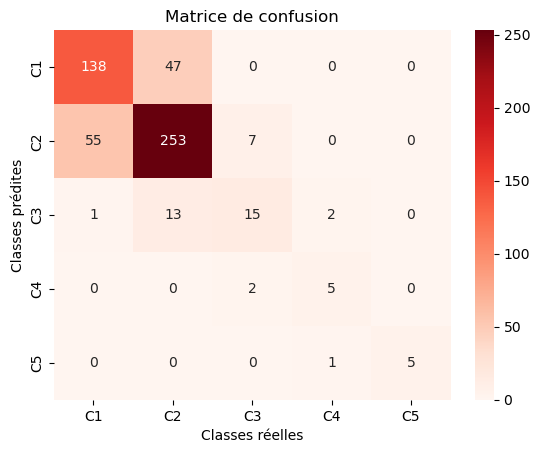

In [81]:
sns.heatmap(matrice_confusion(), annot=True, fmt="d", xticklabels=np.unique(y), yticklabels=np.unique(y), cmap="Reds")
plt.xlabel("Classes réelles")
plt.ylabel("Classes prédites")
plt.title("Matrice de confusion")
plt.show()

<Axes: >

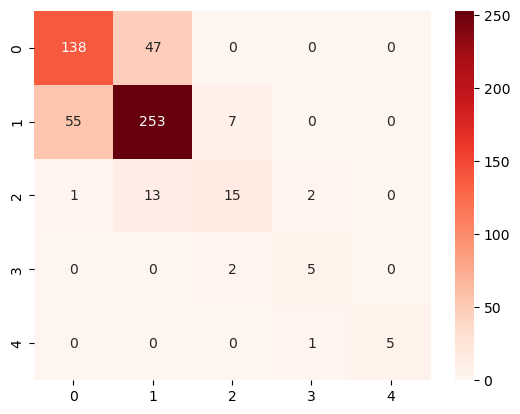

In [83]:
# Matrice de confusion en utilisant Scikit-Learn
from sklearn.metrics import confusion_matrix
cf_matrix = confusion_matrix(y, predict)
cf_matrix
sns.heatmap(cf_matrix, annot=True, fmt="d", cmap="Reds")

In [140]:
def precalc_stats(X, Y):
    classes = np.unique(Y)
    stats = {}
    for c in classes:
        indices = Y['classification_diagnostic'] == c
        stats[c] = {
            "class_prior": len(Y[indices]) / len(Y),
            "feature_probs": {
                col: (X[indices][col].value_counts() ) / (len(Y[indices]))
                for col in X.columns
            }
        }
    return stats

In [164]:
precalc_stats(x, y)

{'C1': {'class_prior': 0.3400735294117647,
  'feature_probs': {'type_sol': type_sol
   Gr    0.427027
   MA    0.291892
   S     0.145946
   GR    0.086486
   CS    0.032432
   G     0.010811
   TV    0.005405
   Name: count, dtype: float64,
   'classe_age': classe_age
   J     0.416216
   A     0.313514
   JA    0.270270
   Name: count, dtype: float64,
   'classe_hauteur': classe_hauteur
   H1    0.664865
   H2    0.297297
   H3    0.037838
   Name: count, dtype: float64,
   'classe_circonference': classe_circonference
   C1    0.708108
   C2    0.286486
   C3    0.005405
   Name: count, dtype: float64,
   'port_arbre': port_arbre
   SL    0.378378
   R5    0.324324
   L     0.297297
   Name: count, dtype: float64,
   'vigueur_pousse': vigueur_pousse
   P     0.891892
   PP    0.102703
   MP    0.005405
   Name: count, dtype: float64,
   'plaie_collet': plaie_collet
   RCPPL    0.886486
   RCPLS    0.097297
   RCPLC    0.016216
   Name: count, dtype: float64,
   'fissure_tronc': fissu

In [142]:
def predict(X, stats):
    classes = list(stats.keys())
    probs = np.zeros((len(X), len(classes)))
    
    for idx, c in enumerate(classes):
        log_prob = np.log(stats[c]["class_prior"])  # log P(Y)
        for col in X.columns:
            probs_col = stats[c]["feature_probs"][col]
            log_prob += np.log(X[col].map(probs_col).fillna(1 / len(probs_col)))  # log P(X|Y)
        probs[:, idx] = log_prob
    return np.array(classes)[np.argmax(probs, axis=1)]

In [144]:
predict = predict(x, precalc_stats(x, y))

In [150]:
taux_erreur(predict, y)

Taux d'erreur : 36.76471%
